<a href="https://colab.research.google.com/github/hema1573/House-prices-/blob/main/day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("heart1.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oledpeak  ca  target
0   49    0   3       177   150    0       95      0       2.3   0       0
1   56    1   0       124   172    1       86      1       0.5   0       1
2   66    0   3       100   239    0      105      0       1.7   0       0
3   64    0   0       168   222    0       95      1       2.8   0       1
4   48    1   2       153   358    0      147      0       3.2   0       1
1    7
0    3
Name: target, dtype: int64


In [ ]:
print(df.info())
print(df.describe())
print(df.isnull())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10 non-null     int64  
 1   sex       10 non-null     int64  
 2   cp        10 non-null     int64  
 3   trestbps  10 non-null     int64  
 4   chol      10 non-null     int64  
 5   fbs       10 non-null     int64  
 6   thalach   10 non-null     int64  
 7   exang     10 non-null     int64  
 8   oledpeak  10 non-null     float64
 9   ca        10 non-null     int64  
 10  target    10 non-null     int64  
dtypes: float64(1), int64(10)
memory usage: 1008.0 bytes
None
             age        sex         cp   trestbps        chol        fbs  \
count  10.000000  10.000000  10.000000   10.00000   10.000000  10.000000   
mean   54.000000   0.600000   1.600000  144.60000  250.300000   0.200000   
std     9.321421   0.516398   1.429841   30.65652   88.796959   0.421637   
min    38.000000   0.0000

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
 x,y,test_size = 0.2,random_state =42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter = 1000)
model.fit(x_train,y_train)
pred=model.predict(x_test)
print(pred[ :10])

[1 0]


In [ ]:
from sklearn.metrics import (
accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
)
acc= accuracy_score(y_test,pred)
cm=confusion_matrix(y_test,pred)
prec=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
print(acc,prec,rec,f1)
print(cm)

0.0 0.0 0.0 0.0
[[0 1]
 [1 0]]


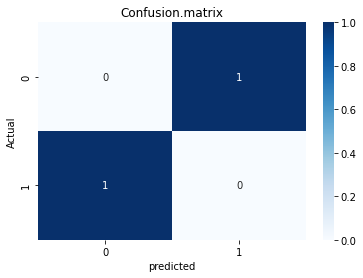

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion.matrix")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
pred_knn=knn.predict(x_test)
print(accuracy_score(y_test,pred_knn))

0.5


In [ ]:
for k in [1,3,5,7]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    pred_k=knn.predict(x_test)
    acc_k=accuracy_score(y_test,pred_k)
    print("k=","-> Accuracy:",acc_k)

k= -> Accuracy: 0.5
k= -> Accuracy: 0.5
k= -> Accuracy: 0.5
k= -> Accuracy: 0.5
